In [46]:
from lifelines import KaplanMeierFitter
from lifelines import AalenJohansenFitter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lifelines import CoxPHFitter

In [47]:
#Dataframe Notes: 0 = cancer (relapse?), 1 = lost to follow up, 2 = death, competiting
#DT_SECONDCANCER_DEATH, ENDPT_SECONDCANCER_DEATH,
df = pd.read_csv(r"C:\Users\Charm\Downloads\data_clinical_sample_ttnext_cancer_6-2-26.csv")

C:\Users\Charm\AppData\Local\Temp\ipykernel_6172\80286513.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Charm\Downloads\data_clinical_sample_ttnext_cancer_6-2-26.csv")


In [48]:
sorted_df = df.sort_values(by = 'CURRENT_AGE_DEID')
dt = sorted_df['DT_SECONDCANCER_DEATH']
censored_val = sorted_df['ENDPT_SECONDCANCER_DEATH']
curr_age = sorted_df['CURRENT_AGE_DEID']

Lets just look at first biopsies then go from there. Update: No repeating patients, so it's okay!

In [49]:
df['SAMPLE_ID'].duplicated().sum()

np.int64(0)

In [51]:
#If time is negative, set it to 0.
#sorted_df.loc[sorted_df['DT_SECONDCANCER_DEATH']<0, 'DT_SECONDCANCER_DEATH'] = 0
#DT_SECONDCANCER_DEATH is Last Date - Start Date, is start date when the patient was diagnosed cancer free from the primary lung cancer and then we're tracking how long it takes for the patient to die or develop second primary lung cancer or is lost to follow up, or is start date the day the patient was diagnosed with the first cancer? The former makes more sense, so I'm assuming the data is left censored and instead of just setting those dates to 0, I'll remove  them.
sorted_df = sorted_df.loc[(sorted_df['DT_SECONDCANCER_DEATH']>=0).values]

In [57]:
#If we only want 1 to represent the observed effect
sorted_df['Event_of_interest'] =(sorted_df['ENDPT_SECONDCANCER_DEATH'] == 1).astype(int)
sorted_df['Event_of_interest']

11896    0
2874     0
1280     0
9170     0
2305     0
        ..
4205     1
10505    0
4225     0
4226     0
8404     0
Name: Event_of_interest, Length: 12128, dtype: int64

<Axes: >

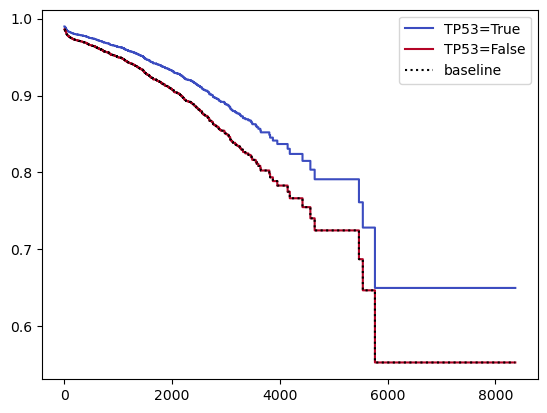

In [87]:
#Filter the df so that I don't get a value error because of the text columns...
cph_df = sorted_df[['DT_SECONDCANCER_DEATH', 'Event_of_interest', 'TP53', 'CURRENT_AGE_DEID', 'KRAS', 'EGFR', 'ALK', 'BRAF', 'ROS1', 'MET']]
cph = CoxPHFitter()
cph.fit(cph_df, duration_col = 'DT_SECONDCANCER_DEATH', event_col = 'Event_of_interest')
cph.plot_partial_effects_on_outcome(covariates='TP53', values=[True, False], cmap='coolwarm')

Proportional Hazard Assumption: All Individuals have the same hazard function and differ by a scalar, and that scalar does not vary with time.

In [95]:
cph.print_summary(model = 'untransformed variables', decimals = 3)

C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\coxph_fitter.py:2748: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, _df in self._predicted_partial_hazards_.groupby(self.strata):


AttributeError: The '.style' accessor requires jinja2

model,lifelines.CoxPHFitter
duration col,'DT_SECONDCANCER_DEATH'
event col,'Event_of_interest'
robust variance,True
strata,Age Buckets
baseline estimation,breslow
number of observations,12128
number of events observed,729
partial log-likelihood,-5665.441
time fit was run,2026-06-10 13:55:20 UTC
model,untransformed variables


In [88]:
#[i for i in sorted_df['CURRENT_AGE_DEID'].values]

In [89]:
#cph.fit(cph_df, duration_col = 'DT_SECONDCANCER_DEATH', event_col = 'Event_of_interest')
#cph.plot_partial_effects_on_outcome(covariates='CURRENT_AGE_DEID', values=[i for i in sorted_df['CURRENT_AGE_DEID'].values], cmap='coolwarm')


In [90]:
print(sorted_df['Event_of_interest'].dtypes, sorted_df['DT_SECONDCANCER_DEATH'].dtypes)

int64 int64


Let's make a cumulative incidence function, since lifelines doesn't have fine gray, we can use Aalen Johansen but it doesn't account for covariants (whereas the Cox Proportional Hazard Function accounts for covariants but not for competing factors...)

             CIF_1
event_at          
0.0       0.000000
1.0       0.000083
2.0       0.000166
3.0       0.000166
5.0       0.000166
...            ...
7355.0    0.454490
7498.0    0.454490
7853.0    0.454490
8305.0    0.454490
8372.0    0.454490

[3143 rows x 1 columns]


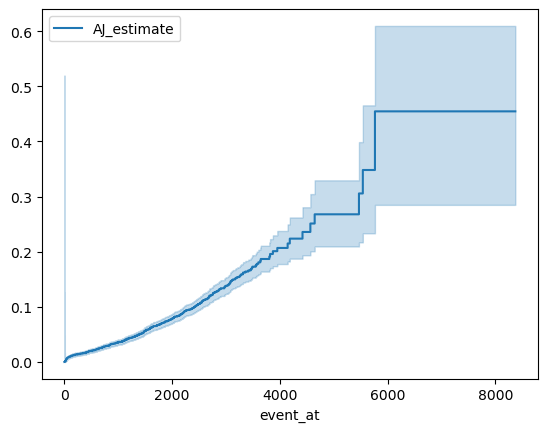

In [91]:
ajf = AalenJohansenFitter(calculate_variance = True)
ajf.fit(cph_df['DT_SECONDCANCER_DEATH'], cph_df['Event_of_interest'], event_of_interest=1)
print(ajf.cumulative_density_)
#ajf.plot()
ajf.plot_cumulative_density()

So the rate for someone who has experienced a first primary cancer experiencing a second primary cancer is 46% ?

Let's stratifying between people with TP53 mutation and those without.

In [92]:
mutated_TP53 = cph_df[cph_df['TP53'] == True]
nonmutated_TP53 = cph_df[cph_df['TP53'] == False]

<Axes: xlabel='event_at'>

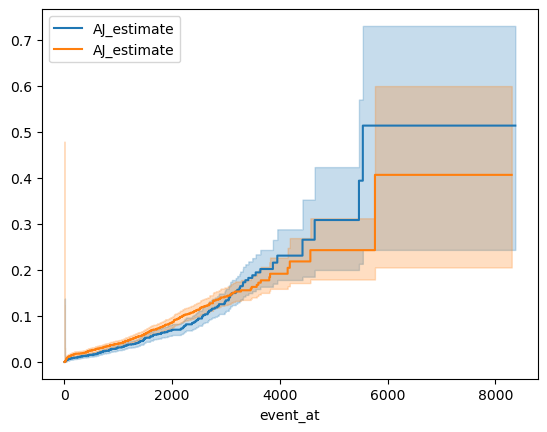

In [93]:
ajf.fit(mutated_TP53['DT_SECONDCANCER_DEATH'], mutated_TP53['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(nonmutated_TP53['DT_SECONDCANCER_DEATH'], nonmutated_TP53['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
#Blue is mutated, Orange is unmutated

C:\Users\Charm\AppData\Local\Temp\ipykernel_6172\914604884.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cph_df['Age Buckets'] = pd.cut(sorted_df['CURRENT_AGE_DEID'], bins=[0, 25, 75, 100], labels=['0-24', '25-74', '75-100'])
C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\__init__.py:1284: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, df_ in df.groupby(strata):
C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1868: FutureWarning: The default of observed=F

<Axes: xlabel='log(HR) (95% CI)'>

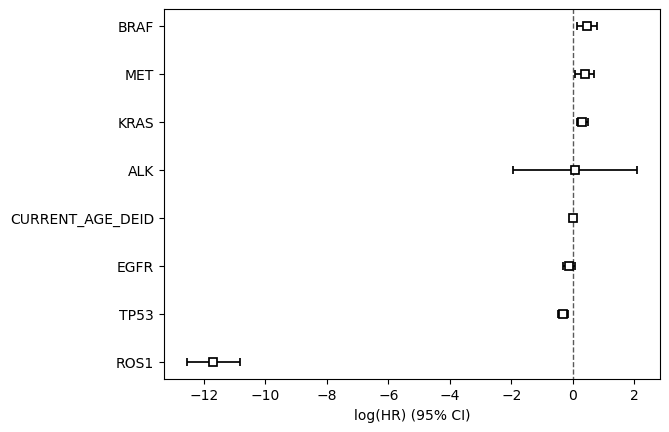

In [94]:
cph_df['Age Buckets'] = pd.cut(sorted_df['CURRENT_AGE_DEID'], bins=[0, 25, 75, 100], labels=['0-24', '25-74', '75-100'])
#print(cph_df['Age Buckets'])
cph.fit(cph_df, duration_col = 'DT_SECONDCANCER_DEATH', event_col = 'Event_of_interest', strata = 'Age Buckets', robust = True)
cph.plot()

If the individual developed a secondary cancer, lets see how high the incidence is for someone with a TP53 and KRAS mutation

<Axes: xlabel='event_at'>

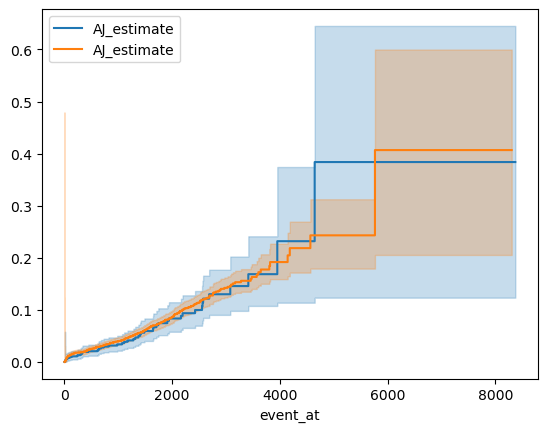

In [65]:
mutated_TP53_KRAS = mutated_TP53[mutated_TP53['KRAS'] == True]
ajf.fit(mutated_TP53_KRAS['DT_SECONDCANCER_DEATH'], mutated_TP53_KRAS['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(nonmutated_TP53['DT_SECONDCANCER_DEATH'], nonmutated_TP53['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

Lets look at how age impacts CIF


<Axes: xlabel='event_at'>

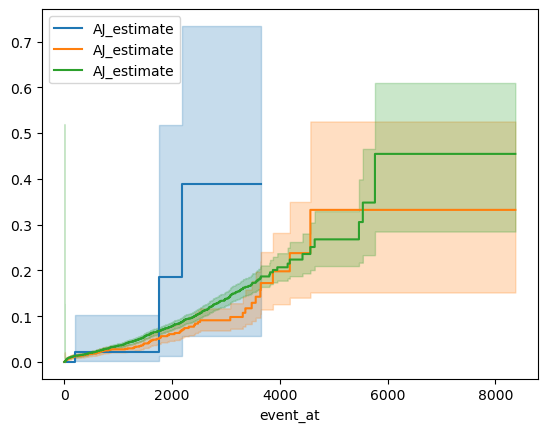

In [66]:
group_1 = cph_df[cph_df['CURRENT_AGE_DEID'] <= 32]
group_2 = cph_df[cph_df['CURRENT_AGE_DEID'] <= 65]
group_3 = cph_df[cph_df['CURRENT_AGE_DEID'] <= 99]
ajf.fit(group_1['DT_SECONDCANCER_DEATH'], group_1['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(group_2['DT_SECONDCANCER_DEATH'], group_2['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(group_3['DT_SECONDCANCER_DEATH'], group_3['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
#Blue, orange, green

Let's compare incidence based on stage of cancer.

In [67]:
sorted_df['STAGE_HIGHEST_RECORDED'].unique()

array(['Unknown', 'Stage 1-3', 'Stage 4'], dtype=object)

<Axes: xlabel='event_at'>

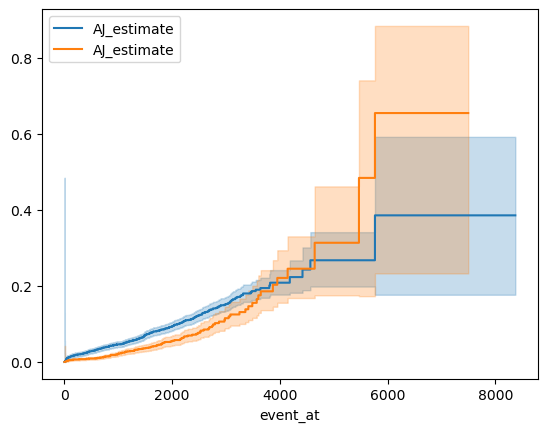

In [68]:
sorted_df_S13 = sorted_df[sorted_df['STAGE_HIGHEST_RECORDED'] == 'Stage 1-3']
group_1 = sorted_df_S13[['DT_SECONDCANCER_DEATH', 'Event_of_interest', 'TP53', 'CURRENT_AGE_DEID', 'KRAS']]
sorted_df_S4 = sorted_df[sorted_df['STAGE_HIGHEST_RECORDED'] == 'Stage 4']
group_2 = sorted_df_S4[['DT_SECONDCANCER_DEATH', 'Event_of_interest', 'TP53', 'CURRENT_AGE_DEID', 'KRAS']]
ajf.fit(group_1['DT_SECONDCANCER_DEATH'], group_1['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(group_2['DT_SECONDCANCER_DEATH'], group_2['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

People diagnosed with Stage 4 primary lung cancer are at a higher risk of a second primary lung cancer than those diagnosed with Stages 1-3 after 10 years...?